In [22]:
import pandas as pd
import time
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import  StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import r2_score, accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay

In [23]:
data_path = "breast_cancer_prediction.csv"

df = pd.read_csv(data_path)

df.head(12)

,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919
5,100006,22,Female,18.8,No,No,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,172,270,No,3,Yes,51320
6,100007,41,Female,31.8,Yes,No,Yes,High,No,Post,...,Normal,Benign,No Cancer,0,176,297,No,7,No,47235
7,100008,72,Male,23.8,No,Yes,No,High,No,Post,...,Normal,Benign,No Cancer,0,164,184,No,5,Yes,102525
8,100009,21,Female,26.1,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,164,238,No,0,Not Applicable,47668
9,100010,49,Female,29.7,Yes,No,Yes,Moderate,No,Pre,...,Normal,Benign,No Cancer,0,177,300,No,0,Yes,83068


In [24]:
# Reading null data
print(f"Missing Values : {df.isnull().sum()}")

Missing Values : Patient_ID                  0
Age                         0
Gender                      0
BMI                       300
Family_History              0
Smoking                     0
Alcohol_Consumption       300
Physical_Activity         300
Hormone_Therapy           300
Menopause_Status            0
Genetic_Mutation            0
Tumor_Size_cm             300
Lymph_Node_Involvement      0
Mammogram_Result            0
Biopsy_Result               0
Cancer_Stage                0
Cancer                      0
Blood_Pressure              0
Cholesterol                 0
Diabetes                    0
Exercise_Days_Per_Week      0
Breastfeeding_History       0
Annual_Income_USD           0
dtype: int64


In [25]:
dfe = df.copy()

dfe = dfe.drop(['Patient_ID'], axis=1)

cat_cols = ['BMI', 'Alcohol_Consumption', 'Physical_Activity', 'Hormone_Therapy', 'Tumor_Size_cm']

cat_imputer = SimpleImputer(strategy='most_frequent')

dfe[cat_cols] = cat_imputer.fit_transform(dfe[cat_cols])

In [26]:
# Reading null data
print(f"Missing Values : \n{dfe.isnull().sum()}")

Missing Values : 
Age                       0
Gender                    0
BMI                       0
Family_History            0
Smoking                   0
Alcohol_Consumption       0
Physical_Activity         0
Hormone_Therapy           0
Menopause_Status          0
Genetic_Mutation          0
Tumor_Size_cm             0
Lymph_Node_Involvement    0
Mammogram_Result          0
Biopsy_Result             0
Cancer_Stage              0
Cancer                    0
Blood_Pressure            0
Cholesterol               0
Diabetes                  0
Exercise_Days_Per_Week    0
Breastfeeding_History     0
Annual_Income_USD         0
dtype: int64


In [27]:
dfe.head(12)

,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,Genetic_Mutation,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,71,Female,27.2,Yes,Yes,Yes,High,No,Post,Positive,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,34,Male,26.0,No,No,No,High,No,Post,Negative,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,80,Female,20.7,No,No,No,High,No,Pre,Negative,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,Negative,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,Negative,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919
5,22,Female,18.8,No,No,No,Moderate,No,Post,Negative,...,Normal,Benign,No Cancer,0,172,270,No,3,Yes,51320
6,41,Female,31.8,Yes,No,Yes,High,No,Post,Positive,...,Normal,Benign,No Cancer,0,176,297,No,7,No,47235
7,72,Male,23.8,No,Yes,No,High,No,Post,Negative,...,Normal,Benign,No Cancer,0,164,184,No,5,Yes,102525
8,21,Female,26.1,No,No,No,High,No,Post,Negative,...,Normal,Benign,No Cancer,0,164,238,No,0,Not Applicable,47668
9,49,Female,29.7,Yes,No,Yes,Moderate,No,Pre,Negative,...,Normal,Benign,No Cancer,0,177,300,No,0,Yes,83068


/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_9450/2769488992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_cols = dfe.select_dtypes(include=['object'])


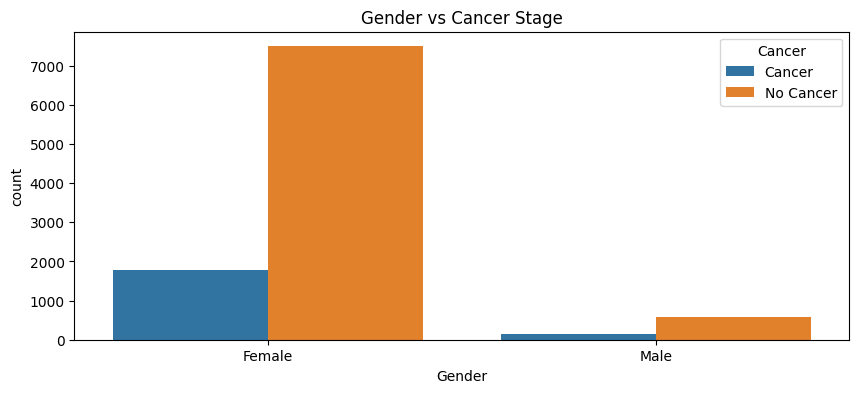

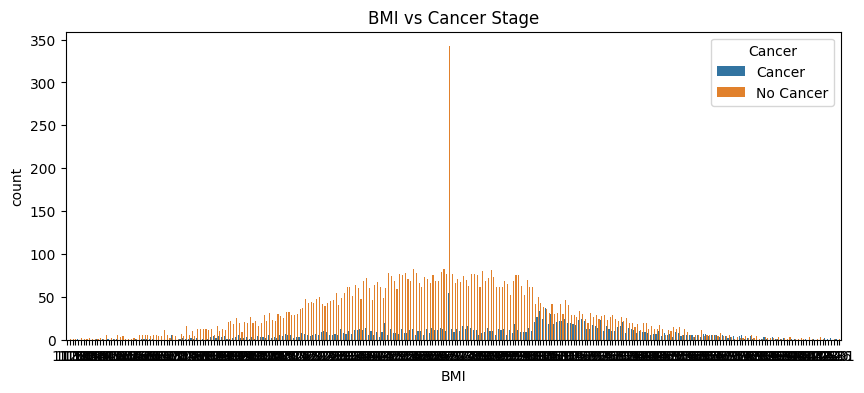

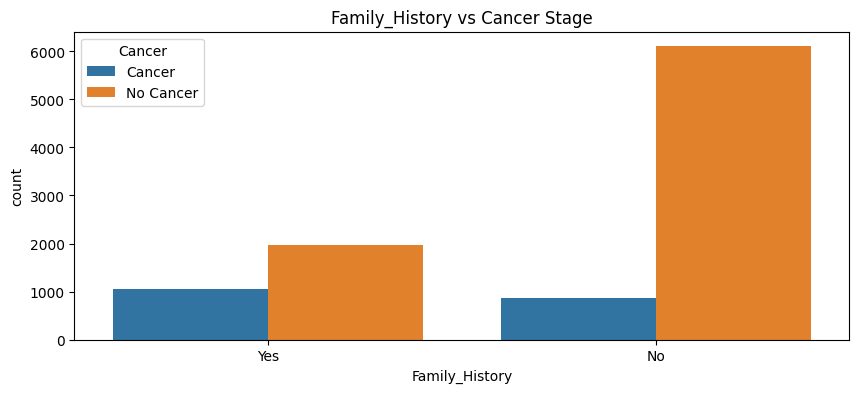

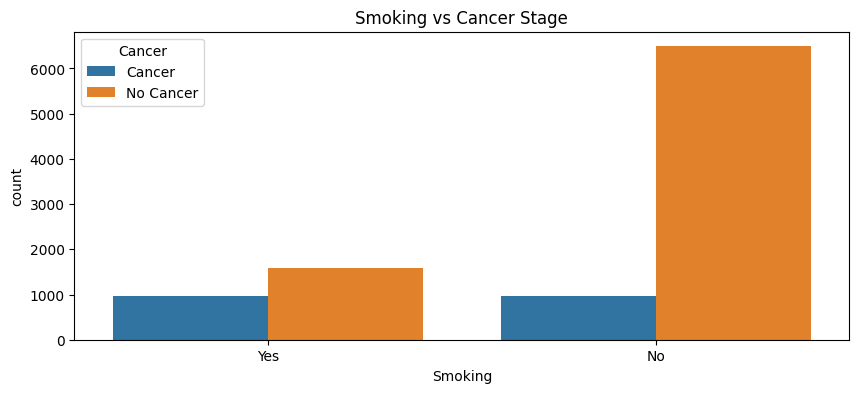

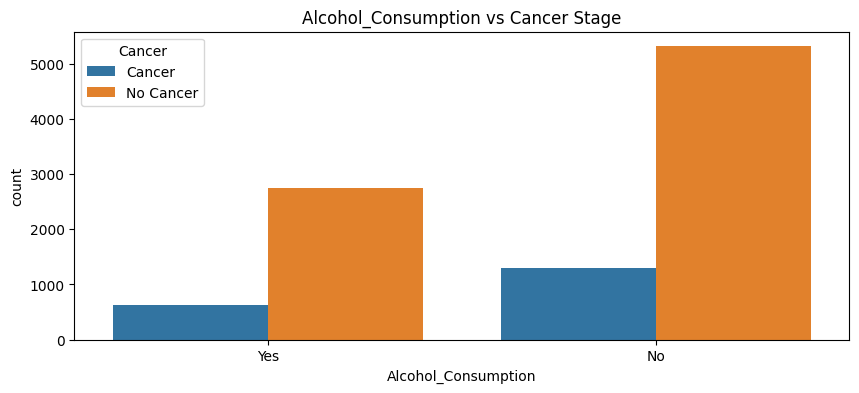

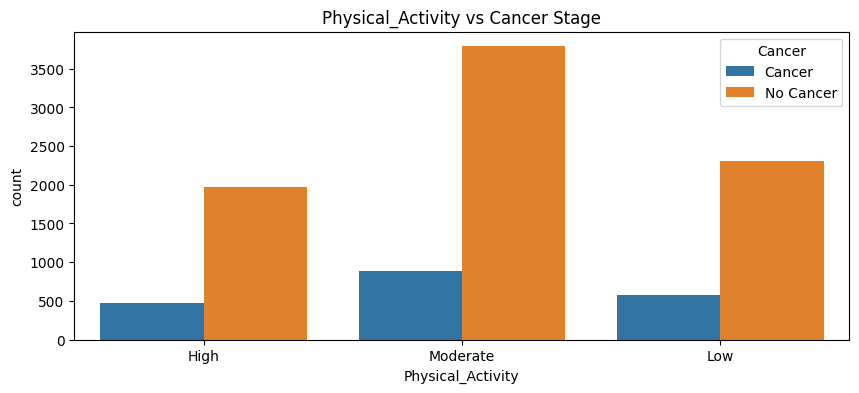

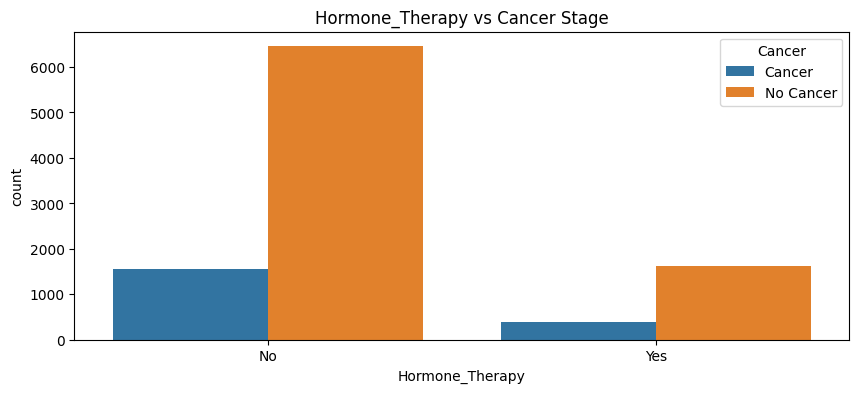

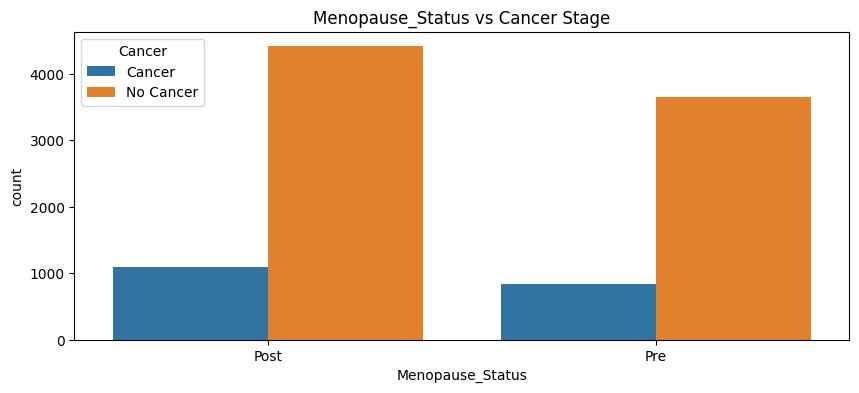

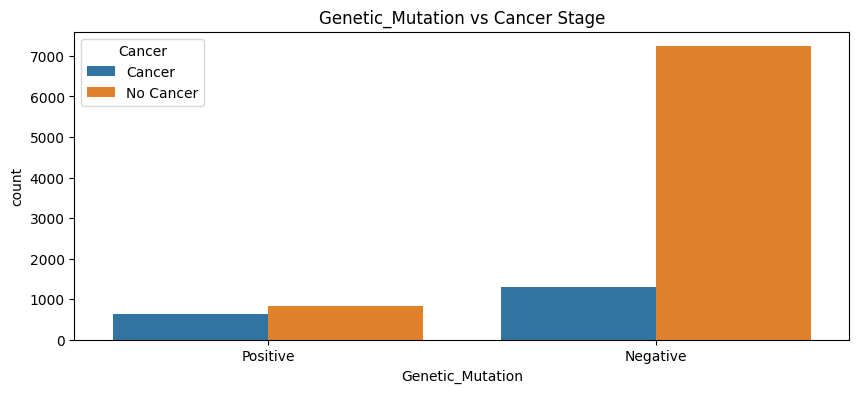

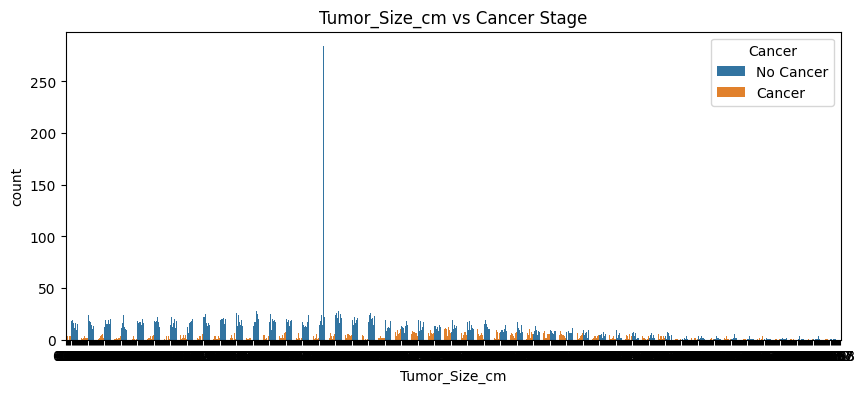

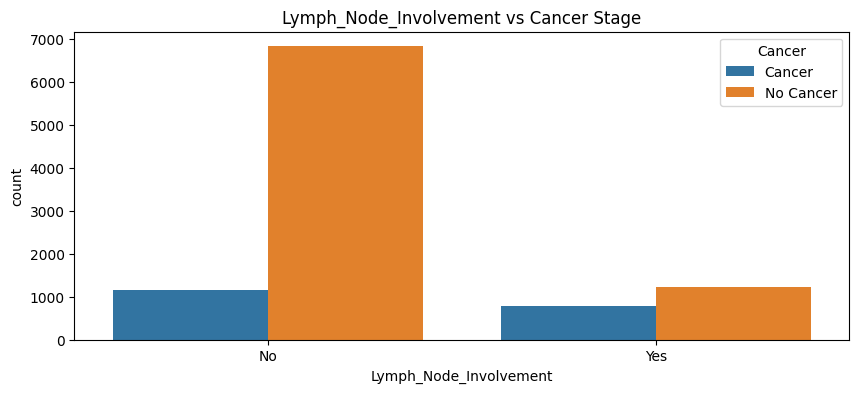

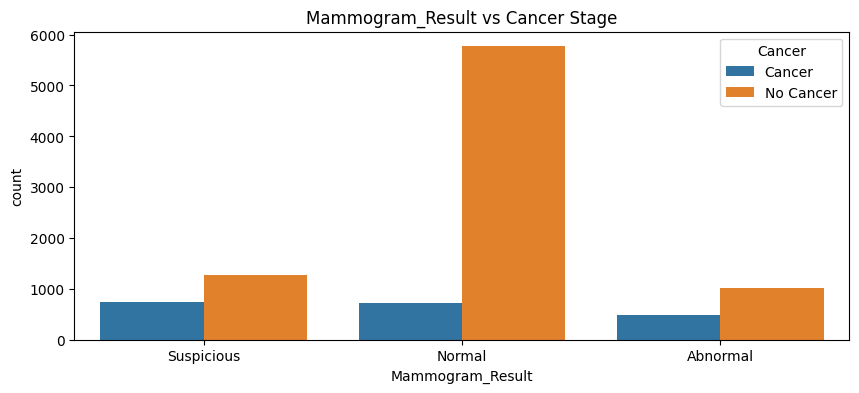

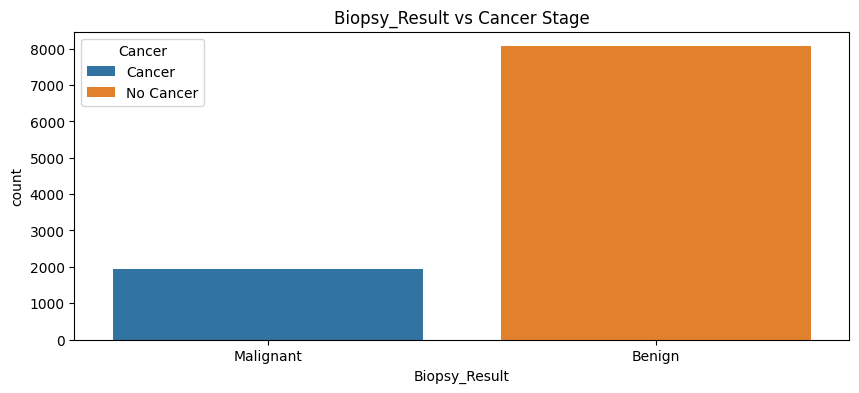

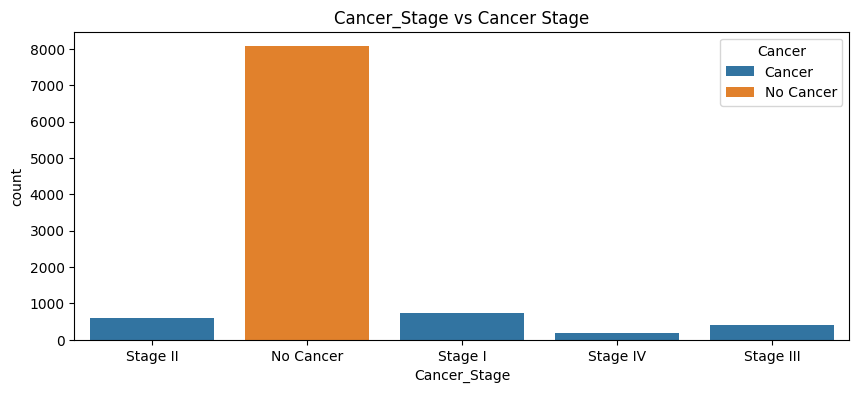

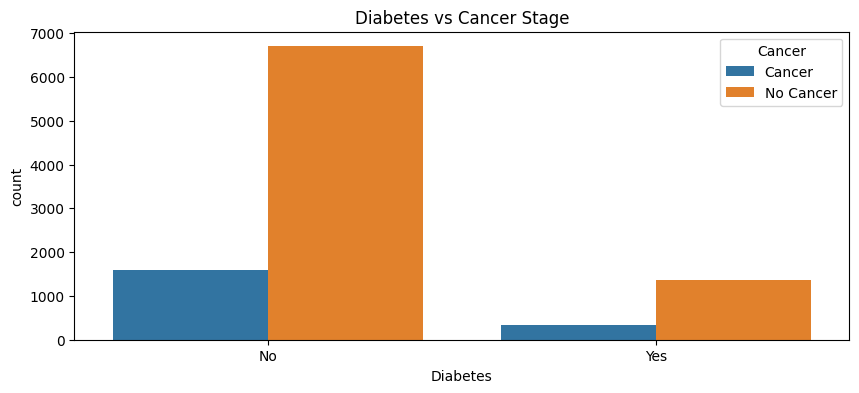

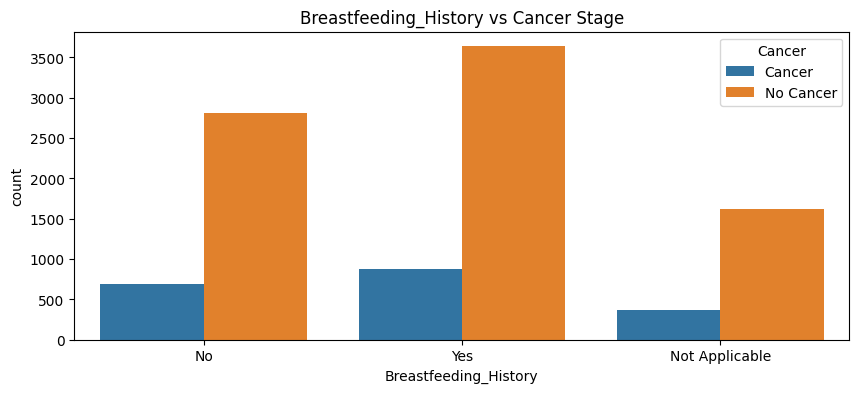

In [28]:

data_cols = dfe.select_dtypes(include=['object'])

dfe_cancer = dfe['Cancer'].map({0: "No Cancer", 1: "Cancer"})

for i in data_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=dfe, x=i, hue=dfe_cancer)
    plt.title(f'{i} vs Cancer Stage')
    plt.xticks(rotation=0)
    plt.show()

In [29]:
object_cols = dfe.select_dtypes(include=['object']).sum()
print(object_cols)

Gender                    FemaleMaleFemaleFemaleFemaleFemaleFemaleMaleFe...
BMI                                                                270496.9
Family_History            YesNoNoYesYesNoYesNoNoYesNoNoNoNoYesNoNoNoNoNo...
Smoking                   YesNoNoYesYesNoNoYesNoNoNoNoYesNoYesNoNoNoNoNo...
Alcohol_Consumption       YesNoNoNoNoNoYesNoNoYesNoYesYesNoNoNoYesNoYesY...
Physical_Activity         HighHighHighModerateModerateModerateHighHighHi...
Hormone_Therapy           NoNoNoNoNoNoNoNoNoNoNoNoNoNoNoNoYesNoNoNoNoNoN...
Menopause_Status          PostPostPrePostPostPostPostPostPostPrePostPost...
Genetic_Mutation          PositiveNegativeNegativeNegativeNegativeNegati...
Tumor_Size_cm                                                      26240.24
Lymph_Node_Involvement    NoNoNoNoNoYesNoNoNoNoNoYesNoNoYesYesNoNoNoYesN...
Mammogram_Result          SuspiciousNormalSuspiciousNormalNormalNormalNo...
Biopsy_Result             MalignantBenignBenignBenignBenignBenignBenignB...
Cancer_Stage

/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_9450/1411472567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = dfe.select_dtypes(include=['object']).sum()


In [30]:
# Scalling Numeric Unique Data

scaller = StandardScaler()

numeric_cols = ['BMI', 'Tumor_Size_cm']

for col in numeric_cols:
    dfe[col] = pd.to_numeric(dfe[col], errors='coerce')
    dfe[col] = dfe[col].fillna(dfe[col].mean())

dfe[numeric_cols] = scaller.fit_transform(dfe[numeric_cols])

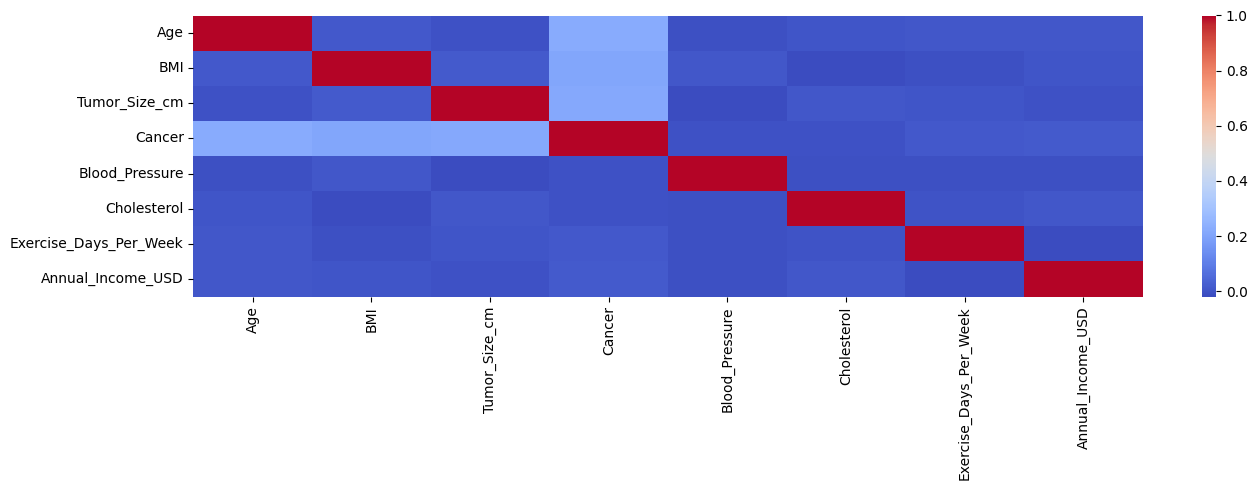

In [31]:
# Heatmap Number Correlation

dfe_number = dfe.select_dtypes(include=['number'])

plt.figure(figsize=(14,5))
sns.heatmap(dfe_number.corr(), cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

In [32]:
dfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     10000 non-null  int64  
 1   Gender                  10000 non-null  str    
 2   BMI                     10000 non-null  float64
 3   Family_History          10000 non-null  str    
 4   Smoking                 10000 non-null  str    
 5   Alcohol_Consumption     10000 non-null  str    
 6   Physical_Activity       10000 non-null  str    
 7   Hormone_Therapy         10000 non-null  str    
 8   Menopause_Status        10000 non-null  str    
 9   Genetic_Mutation        10000 non-null  str    
 10  Tumor_Size_cm           10000 non-null  float64
 11  Lymph_Node_Involvement  10000 non-null  str    
 12  Mammogram_Result        10000 non-null  str    
 13  Biopsy_Result           10000 non-null  str    
 14  Cancer_Stage            10000 non-null  str    
 1

In [33]:
object_cols = dfe.select_dtypes(include=['object'])

for col in object_cols:
    print(f"Unique Value of {col} : {dfe[col].unique()}")

Unique Value of Gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique Value of Family_History : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique Value of Smoking : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique Value of Alcohol_Consumption : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique Value of Physical_Activity : <StringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str
Unique Value of Hormone_Therapy : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique Value of Menopause_Status : <StringArray>
['Post', 'Pre']
Length: 2, dtype: str
Unique Value of Genetic_Mutation : <StringArray>
['Positive', 'Negative']
Length: 2, dtype: str
Unique Value of Lymph_Node_Involvement : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique Value of Mammogram_Result : <StringArray>
['Suspicious', 'Normal', 'Abnormal']
Length: 3, dtype: str
Unique Value of Biopsy_Result : <StringArray>
['Malignant', 'Benign']
Length: 2, dtype: str
Unique Value of

/var/folders/kk/25nr3fln5lndmv7wmy4zdt3h0000gn/T/ipykernel_9450/1552266066.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = dfe.select_dtypes(include=['object'])


In [34]:
binary_cols = ['Family_History', 
               'Smoking', 
               'Alcohol_Consumption',
               'Hormone_Therapy',
               'Lymph_Node_Involvement',
               'Diabetes',
               ]

for cols in binary_cols:
    dfe[cols] = dfe[cols].map({"Yes" : 0, "No" : 1})

dfe['Gender'] = dfe['Gender'].map({"Female" : 0, "Male" : 1})

dfe['Genetic_Mutation'] = dfe['Genetic_Mutation'].map({"Positive" : 0, "Negative" : 1})

dfe['Mammogram_Result'] = dfe['Mammogram_Result'].map({"Normal" : 0, "Abnormal" : 1, "Suspicious" : 2})

dfe['Breastfeeding_History'] = dfe['Breastfeeding_History'].map({"Yes" : 0, "No" : 1, "Not Applicable" : 2})

dfe['Biopsy_Result'] = dfe['Biopsy_Result'].map({"Malignant" : 0, "Benign" : 1})

dfe['Menopause_Status'] = dfe['Menopause_Status'].map({"Post" : 0, "Pre" : 1})

dfe['Cancer_Stage'] = dfe['Cancer_Stage'].map({"No Cancer" : 0, "Stage I" : 1, "Stage II" : 2, "Stage III" : 3, "Stage IV" : 4})

dfe['Physical_Activity'] = dfe['Physical_Activity'].map({"Low" : 0, "Moderate" : 1, "High" : 2})

dfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     10000 non-null  int64  
 1   Gender                  10000 non-null  int64  
 2   BMI                     10000 non-null  float64
 3   Family_History          10000 non-null  int64  
 4   Smoking                 10000 non-null  int64  
 5   Alcohol_Consumption     10000 non-null  int64  
 6   Physical_Activity       10000 non-null  int64  
 7   Hormone_Therapy         10000 non-null  int64  
 8   Menopause_Status        10000 non-null  int64  
 9   Genetic_Mutation        10000 non-null  int64  
 10  Tumor_Size_cm           10000 non-null  float64
 11  Lymph_Node_Involvement  10000 non-null  int64  
 12  Mammogram_Result        10000 non-null  int64  
 13  Biopsy_Result           10000 non-null  int64  
 14  Cancer_Stage            10000 non-null  int64  
 1

In [35]:
print(dfe.isnull().sum()[dfe.isnull().sum() > 0])

Series([], dtype: int64)


In [36]:
print(dfe['Breastfeeding_History'].unique())

[1 0 2]


In [37]:
X = dfe.drop(['Cancer'], axis=1)

y = dfe['Cancer']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, train_size=0.2)

print(f"X train length of data : {len(X_train)}")
print(f"X train length of data : {len(y_train)}")

print(f"\nShape of Data : {dfe.shape}")

X train length of data : 2000
X train length of data : 2000

Shape of Data : (10000, 22)


In [38]:
X = dfe.drop(['Cancer'], axis=1)

y = dfe['Cancer']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, train_size=0.2)

print(f"X train length of data : {len(X_train)}")
print(f"X train length of data : {len(y_train)}")

print(f"\nShape of Data : {dfe.shape}")

X train length of data : 2000
X train length of data : 2000

Shape of Data : (10000, 22)


In [39]:
print(f"Data before rebalancing {len(y_train)}")

smote = SMOTETomek(random_state=2)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Data After rebalancing : {len(y_train_smote)}")

Data before rebalancing 2000
Data After rebalancing : 2692


Time predict : 0.09492862499973853 seconds


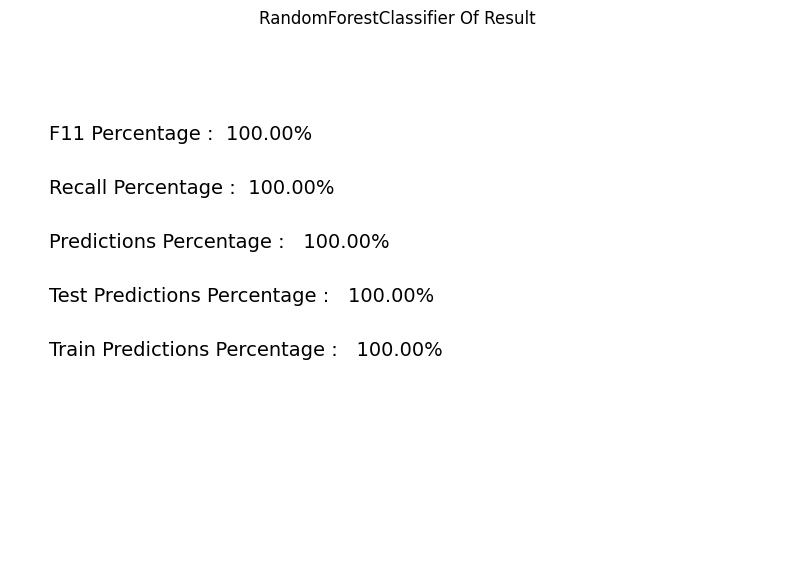

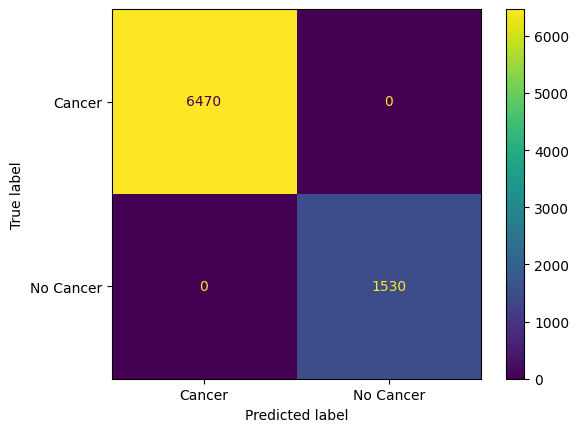


Calculating Learning Curve...


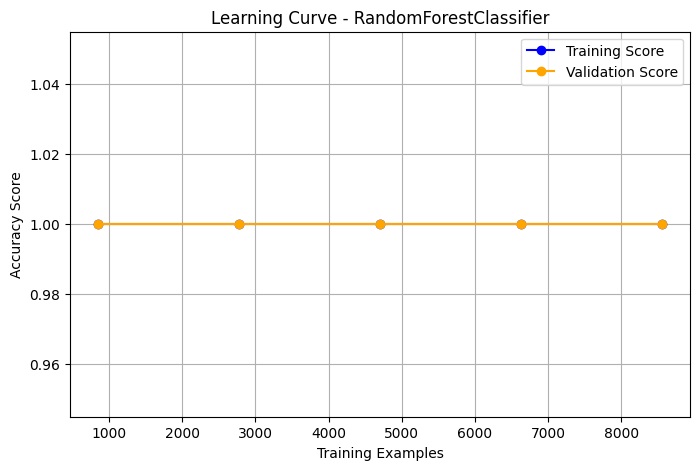

In [41]:
# Classification step using RandomForestClassifier

time_start = time.perf_counter()

model_rfc = RandomForestClassifier(    
    n_estimators=100,      
    max_depth=2,           
    min_samples_split=10,   
    min_samples_leaf=10,    
    random_state=42,
)

model_rfc.fit(X_train_smote, y_train_smote)

train_predictions = model_rfc.predict(X_train_smote)
test_predictions = model_rfc.predict(X_valid)

# Evaluating
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions, average='weighted')
Precision = precision_score(y_valid, test_predictions, average='weighted')
F11 = f1_score(y_valid, test_predictions, average='weighted')
cm = confusion_matrix(y_valid, test_predictions)

print(f"Time predict : {format(time.perf_counter() - time_start)} seconds")

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("RandomForestClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Precision * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cancer", "No Cancer"]).plot()

plt.show()

# Learning Curve
print("\nCalculating Learning Curve...") 

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 5)

X_full = np.vstack((X_train_smote, X_valid)) if hasattr(X_train_smote, 'values') else np.concatenate((X_train_smote, X_valid))
y_full = np.concatenate((y_train_smote, y_valid))

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_rfc,
    X=X_full,
    y=y_full,
    cv=cv_strategy,
    scoring='accuracy',
    train_sizes=train_sizes,
    n_jobs=-1 
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Validation Score")

plt.title("Learning Curve - RandomForestClassifier")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()
